In [1]:
import sys
!git clone -b models/preprocessing https://github.com/duckysmacky/cogniflex.git
%cd cogniflex
%cd /kaggle/working/cogniflex
!pwd
!ls model
sys.path.insert(0, './model')

Cloning into 'cogniflex'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 200 (delta 16), reused 14 (delta 14), pack-reused 173 (from 1)
Receiving objects: 100% (200/200), 448.28 KiB | 724.00 KiB/s, done.
Resolving deltas: 100% (57/57), done.
/kaggle/working/cogniflex
/kaggle/working/cogniflex
/kaggle/working/cogniflex
experiment01_images.ipynb  experiment02_images.ipynb  requirements.txt	utils


In [15]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import matplotlib.pyplot as plt
from utils.preprocess_images import DeepfakeDataset, IMAGE_TRANSFORM_TRAIN, IMAGE_TRANSFORM_VAL, get_images_paths_faces
from utils.visualizations import view_picture
import torchvision.models as models
import torch.nn as nn
from torch.utils.data import DataLoader
import torch

In [5]:
images_paths_train, images_paths_val, labels_train, labels_val  = get_images_paths_faces('/kaggle/input/datasets/ayushmandatta1/deepdetect-2025/ddata')

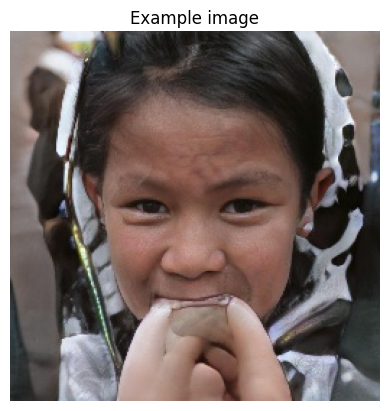

In [16]:
view_picture(images_paths_val[67])

In [20]:
IMAGE_TRANSFORM_TRAIN2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406], #standard values used for dataset ImageNet
        std=[0.229,0.224,0.225]
    )   
])

dataset_train = DeepfakeDataset(images_paths_train, labels_train, transform=IMAGE_TRANSFORM_TRAIN2)
dataset_test = DeepfakeDataset(images_paths_val, labels_val, transform=IMAGE_TRANSFORM_VAL)

train_loader = DataLoader(
    dataset_train ,
    batch_size=32,
    shuffle=True,
    num_workers=3) 

val_loader = DataLoader(
    dataset_test,
    batch_size=32,
    shuffle = False,
    num_workers=1)

len(dataset_train), len(dataset_test)

(90409, 21776)

In [21]:
def train_model_with_early_stopping(num_epochs:int = 20):  

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    #settings for early stopping
    best_val_loss = float('inf') 
    patience = 3                
    epochs_no_improve = 0         
    save_path = "best_resnet_fc.pth"

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}")
        resnet.train()
        train_loss = 0
        train_batches = 0

        for images, labels in train_loader:
            images = images.to(device_pc)
            labels = labels.to(device_pc)

            optimizer.zero_grad()
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_batches += 1
        
        avg_train_loss = train_loss/train_batches
        print(f"Train loss: {avg_train_loss:.4f}")

        resnet.eval()
        val_loss = 0
        correct = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device_pc)
                labels = labels.to(device_pc)

                outputs = resnet(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
        

        avg_val_loss = val_loss / len(val_loader)
        accuracy = correct / len(val_loader.dataset)
        scheduler.step()

        print(f"Val loss: {avg_val_loss:.4f}")
        print(f"Val acc: {accuracy:.4f}")

        # EARLY STOPPING
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            
            torch.save(resnet.state_dict(), save_path)
            print(f"Model saved at epoch {epoch+1}")
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print('There is no improvement')
            break

In [22]:
device_pc = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet = models.resnet18(pretrained=True)

for param in resnet.parameters():
    param.requires_grad = True

resnet.fc = nn.Linear(resnet.fc.in_features, 2)
optimizer = torch.optim.Adam(resnet.parameters(), lr=3e-5, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
resnet = resnet.to(device_pc)
print("Device:", device_pc)

Device: cuda


In [ ]:
train_model_with_early_stopping(10)

Epoch 1
Train loss: 0.2489
Val loss: 0.5571
Val acc: 0.7578
Model saved at epoch 1
Epoch 2
Train loss: 0.1692
Val loss: 0.3785
Val acc: 0.8657
Model saved at epoch 2
Epoch 3
Train loss: 0.1496
Val loss: 0.3591
Val acc: 0.8812
Model saved at epoch 3
Epoch 4
Train loss: 0.1384
Val loss: 0.5062
Val acc: 0.8110
Epoch 5
Train loss: 0.1312


In [23]:
!find /kaggle -name "*.pth"

^C
